<table style="width: 100%; border-collapse: collapse; border: none; background: #f8fafc; border-left: 6px solid #4f46e5; border-radius: 8px; padding: 20px; box-shadow: 0 2px 4px rgba(0,0,0,0.05);">
  <tr style="border: none;">
    <td style="vertical-align: middle; border: none; padding: 15px 20px;">
      <h1 style="margin: 0; color: #0f172a; font-size: 2.1em; font-family: system-ui, -apple-system, sans-serif; font-weight: 800; letter-spacing: -0.02em;">
        Inferencia, CNF y Resolución ⛓️🔍
      </h1>
      <p style="margin: 6px 0 0 0; color: #4f46e5; font-size: 1.15em; font-weight: 600; font-family: system-ui, -apple-system, sans-serif;">
        Especialización en Ciencia de Datos | Introducción a la Inteligencia Artificial
      </p>
      <p style="margin: 4px 0 0 0; color: #64748b; font-size: 0.95em; font-family: system-ui, -apple-system, sans-serif;">
        Universidad Santo Tomás — Seccional Tunja
      </p>
    </td>
    <td style="text-align: right; vertical-align: middle; border: none; padding: 15px 20px; width: 30%;">
      <span style="background: #4f46e5; color: #ffffff; padding: 6px 14px; border-radius: 20px; font-size: 0.85em; font-weight: 700; display: inline-block; margin-bottom: 8px;">
        Módulo 05 • Agentes de Conocimiento
      </span><br>
      <span style="color: #64748b; font-size: 0.85em;">Docente: Santiago A. Zúñiga M.</span><br>
      <a href="mailto:gestorvirtualcienciadatos@ustatunja.edu.co" style="color: #4f46e5; font-size: 0.8em; text-decoration: none; font-weight: 500;">gestorvirtualcienciadatos@ustatunja.edu.co</a>
    </td>
  </tr>
</table>


---
## 🎯 Objetivos de Aprendizaje

Cerramos el capítulo de Agentes Basados en Conocimiento abordando **cómo inferir de forma más eficiente** que enumerando fuerza bruta. Al finalizar podrás:

1. Explicar por qué `model_check` es correcto pero **computacionalmente costoso** ($O(2^n)$).
2. Distinguir el encadenamiento hacia adelante/atrás (para reglas tipo Horn) de la **resolución** (para lógica proposicional general).
3. Convertir cualquier sentencia proposicional a **Forma Normal Conjuntiva (CNF)**.
4. Aplicar la **regla de resolución** como mecanismo de inferencia por refutación.
5. Resolver dos acertijos lógicos completos (`futbol.py`, `perdidos.py`) comparando `model_check` contra `resolution_entails`.


---
## 1. Inferencia en Agentes Basados en Conocimiento (1.17.7)

`model_check` es un algoritmo **correcto** (nunca da una respuesta equivocada) y **completo** (siempre encuentra la respuesta si existe), pero su costo crece **exponencialmente** con el número de símbolos: para $n$ símbolos hay que examinar $2^n$ modelos.

| Símbolos ($n$) | Modelos a examinar ($2^n$) |
|---|---|
| 5 | 32 |
| 10 | 1.024 |
| 20 | 1.048.576 |
| 30 | 1.073.741.824 |
| 50 | ≈ $1{,}1 \times 10^{15}$ |

Existen dos grandes alternativas más eficientes:

* **Encadenamiento hacia adelante / hacia atrás** (*forward / backward chaining*): extremadamente eficientes, pero solo aplicables cuando todas las reglas son **cláusulas de Horn** (a lo sumo un literal positivo por regla, del estilo `a ∧ b ∧ c → d`). El encadenamiento hacia adelante parte de los hechos conocidos y dispara reglas hasta saturar la KB; el encadenamiento hacia atrás parte de la consulta y busca reglas que la respalden, recursivamente.
* **Resolución**: funciona para **cualquier** sentencia de lógica proposicional (no solo cláusulas de Horn), siempre que la sentencia esté en **Forma Normal Conjuntiva (CNF)**. Es el método que implementaremos en este cuaderno.

Midamos empíricamente el costo real de `model_check` a medida que crece el número de símbolos:


In [ ]:
import sys, os, time
sys.path.append(os.getcwd())

from logic import Symbol, And, model_check

print(f"{'n símbolos':>10} | {'2^n modelos':>12} | {'tiempo (s)':>10}")
print("-" * 38)
for n in [5, 10, 14, 18, 20]:
    simbolos = [Symbol(f"S{i}") for i in range(n)]
    kb = And(*simbolos)  # KB trivial: todos los símbolos son verdaderos.
    consulta = simbolos[0]

    inicio = time.time()
    resultado = model_check(kb, consulta)
    duracion = time.time() - inicio

    print(f"{n:>10} | {2**n:>12,} | {duracion:>10.3f}")


El crecimiento es evidente: duplicar el número de símbolos multiplica por mucho más que el doble el tiempo de cómputo. En problemas reales con decenas o cientos de símbolos, `model_check` por fuerza bruta deja de ser viable — de allí la importancia de algoritmos como la **resolución**.

---
## 2. Forma Normal Conjuntiva (CNF) en Python (1.17.8)

Una sentencia está en **Forma Normal Conjuntiva (CNF)** si tiene la forma de una **conjunción de cláusulas**, donde cada **cláusula** es una **disyunción de literales** (un literal es un símbolo o su negación):

$$\underbrace{(\ell_{1,1} \vee \ell_{1,2} \vee \dots)}_{\text{cláusula 1}} \wedge \underbrace{(\ell_{2,1} \vee \ell_{2,2} \vee \dots)}_{\text{cláusula 2}} \wedge \dots$$

**Toda** sentencia de lógica proposicional puede convertirse a una CNF lógicamente equivalente mediante un pipeline de transformaciones sintácticas, implementado en `logic.py` como `to_cnf()`:

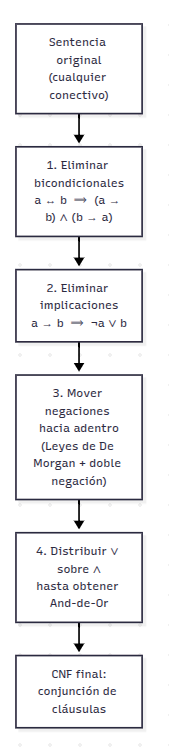

Veamos el pipeline completo en acción sobre una sentencia con bicondicional:


In [ ]:
from logic import Symbol, Not, And, Or, Implication, Biconditional, to_cnf, to_clauses, formula_of_clause

A = Symbol("A")
B = Symbol("B")
C = Symbol("C")

original = Biconditional(A, Or(B, C))
cnf = to_cnf(original)
clausulas = to_clauses(cnf)

print(f"Sentencia original : {original.formula()}")
print(f"CNF equivalente    : {cnf.formula()}")
print("\nCláusulas (cada una es una disyunción de literales):")
for c in clausulas:
    print(f"  {formula_of_clause(c)}")


---
## 3. Resolución como Regla de Inferencia

La **regla de resolución** combina dos cláusulas que comparten un literal complementario (por ejemplo, $P$ en una y $\neg P$ en la otra) en una nueva cláusula (el **resolvente**), que contiene la unión de los literales restantes:

$$\dfrac{(\ell_1 \vee \dots \vee P \vee \dots) \quad (\neg P \vee m_1 \vee \dots)}{(\ell_1 \vee \dots \vee m_1 \vee \dots)}$$

El algoritmo de **inferencia por refutación** usa esta regla así: para probar $KB \models \alpha$, se asume lo contrario ($KB \wedge \neg\alpha$), se convierte a CNF y se aplican resoluciones entre pares de cláusulas repetidamente. Si en algún momento se deriva la **cláusula vacía** ($\square$, una contradicción), entonces $KB \wedge \neg\alpha$ es insatisfacible, lo que demuestra que $KB \models \alpha$.

```mermaid
flowchart TD
    A["KB ∧ ¬consulta, convertido a CNF"] --> B["Conjunto de cláusulas"]
    B --> C{"¿Existen dos cláusulas\ncon literales complementarios?"}
    C -- Sí --> D["Resolver el par:\ngenerar cláusula(s) nueva(s)"]
    D --> E{"¿Se derivó la\ncláusula vacía ☐?"}
    E -- Sí --> F["Contradicción: KB ⊨ consulta -> True"]
    E -- No --> G["Agregar resolventes\nal conjunto de cláusulas"]
    G --> C
    C -- No hay más pares nuevos --> H["No hay contradicción: KB ⊨ consulta -> False"]
```

Esto es exactamente lo que implementa `resolution_entails(knowledge, query)` en `logic.py`. Probemos la regla `resolve()` manualmente sobre dos cláusulas:


In [ ]:
from logic import resolve

# Cláusula 1: (P ∨ Q)   -- representada como {(P, True), (Q, True)}
c1 = frozenset({("P", True), ("Q", True)})
# Cláusula 2: (¬P ∨ R)  -- representada como {(P, False), (R, True)}
c2 = frozenset({("P", False), ("R", True)})

resolventes = resolve(c1, c2)

print(f"Cláusula 1: {formula_of_clause(c1)}")
print(f"Cláusula 2: {formula_of_clause(c2)}")
print("Resolvente(s):")
for r in resolventes:
    print(f"  {formula_of_clause(r)}")


El literal `P` en la cláusula 1 y `¬P` en la cláusula 2 son complementarios, así que la resolución produce `(Q ∨ R)`: si $P$ es falso (para satisfacer la cláusula 2 necesitamos $R$, salvo que $P$ sea verdadero) y $P$ es verdadero (para satisfacer la cláusula 1 necesitamos $Q$, salvo que $P$ sea falso), entonces en cualquier caso debe cumplirse $Q \vee R$.

---
## 4. Caso de Aplicación 1: ¿Quién ganó el partido? ⚽

**Escenario:** el partido entre el equipo Local y el equipo Visitante terminó, y solo pudo ocurrir **uno** de tres resultados posibles (ganó el Local, ganó el Visitante, o hubo empate — mutuamente excluyentes). Dos pistas periodísticas permiten descartar dos de las tres opciones.

El archivo [`futbol.py`](futbol.py) codifica este acertijo y lo resuelve con **ambos** métodos de inferencia, comparándolos:


In [ ]:
import futbol as caso_futbol
from logic import model_check, resolution_entails

print(f"Base de conocimiento:\n  {caso_futbol.knowledge.formula()}\n")

print("CNF (cláusulas):")
for c in caso_futbol.to_clauses(caso_futbol.to_cnf(caso_futbol.knowledge)):
    print(f"  {caso_futbol.formula_of_clause(c)}")

consulta = caso_futbol.VISITANTE
print(f"\nConsulta: ¿Ganó el equipo Visitante? -> {consulta.formula()}")
print(f"  [Model Checking]  -> {model_check(caso_futbol.knowledge, consulta)}")
print(f"  [Resolución CNF]  -> {resolution_entails(caso_futbol.knowledge, consulta)}")


---
## 5. Caso de Aplicación 2: ¿Quién se perdió en la salida de campo? 🧭

**Escenario:** durante una salida de campo geológica, exactamente **uno** de tres estudiantes (Ana, Beto o Caro) se perdió en la montaña. Dos testimonios del guía permiten descartar a dos de los tres sospechosos.

El archivo [`perdidos.py`](perdidos.py) codifica este segundo acertijo, con la misma estructura lógica que el caso anterior pero un dominio distinto:


In [ ]:
import perdidos as caso_perdidos

print(f"Base de conocimiento:\n  {caso_perdidos.knowledge.formula()}\n")

print("CNF (cláusulas):")
for c in caso_perdidos.to_clauses(caso_perdidos.to_cnf(caso_perdidos.knowledge)):
    print(f"  {caso_perdidos.formula_of_clause(c)}")

consulta2 = caso_perdidos.PC
print(f"\nConsulta: ¿Se perdió Caro? -> {consulta2.formula()}")
print(f"  [Model Checking]  -> {model_check(caso_perdidos.knowledge, consulta2)}")
print(f"  [Resolución CNF]  -> {resolution_entails(caso_perdidos.knowledge, consulta2)}")


---
## 6. Model Checking vs. Resolución: ¿Cuándo usar cada uno?

| Criterio | Model Checking (fuerza bruta) | Resolución sobre CNF |
|---|---|---|
| **Corrección** | Correcto y completo | Correcto y completo |
| **Complejidad** | $O(2^n)$ siempre | Depende de la estructura; en la práctica suele ser mucho más eficiente |
| **Facilidad de implementación** | Muy simple (enumerar y evaluar) | Requiere el pipeline de conversión a CNF |
| **Escalabilidad** | Mala para $n$ grande | Base de los **SAT solvers** industriales modernos, capaces de resolver problemas con millones de variables |
| **Uso típico en este curso** | Validar entendimiento conceptual de la implicación lógica | Introducir el mecanismo detrás de motores de inferencia reales |

En la práctica profesional, ningún motor de inferencia industrial usa fuerza bruta: los **SAT/SMT solvers** modernos (usados en verificación de software, planificación, criptografía y más) son descendientes directos de la resolución, con décadas de optimizaciones (aprendizaje de cláusulas, propagación unitaria, heurísticas de ramificación).


---
## Resumen / Puntos Clave

* `model_check` es correcto pero exponencial ($O(2^n)$); no escala a bases de conocimiento grandes.
* El **encadenamiento hacia adelante/atrás** es muy eficiente pero solo aplica a **cláusulas de Horn** (reglas con un único literal positivo).
* La **resolución** es un método general: convierte la sentencia a **CNF** (conjunción de cláusulas, cada una disyunción de literales) y aplica la regla de resolución para buscar una contradicción por refutación.
* `logic.py` implementa el pipeline completo de conversión a CNF (`to_cnf`, `to_clauses`) y el algoritmo de inferencia por resolución (`resolve`, `resolution_entails`).
* Los casos `futbol.py` y `perdidos.py` demuestran que **model checking** y **resolución** siempre coinciden en su respuesta — son dos caminos distintos hacia la misma verdad lógica, con costos computacionales muy diferentes.

### 🧠 Autoevaluación

1. Explica, con tus propias palabras, por qué la resolución busca derivar la **cláusula vacía** para demostrar que $KB \models \alpha$. ¿Qué significa lógicamente que una cláusula quede vacía?
2. Convierte a mano (en papel) la sentencia $A \rightarrow (B \wedge C)$ a CNF, siguiendo el pipeline de 4 pasos, y verifica tu resultado con `to_cnf()`.
3. En los casos `futbol.py` y `perdidos.py`, ¿por qué fue necesario incluir las cláusulas de exclusión mutua (`Not(And(...))`) además de la disyunción `Or(...)`? ¿Qué pasaría con la inferencia si se omitieran?
4. ¿Por qué crees que los SAT solvers industriales modernos se basan en resolución y no en verificación de modelos por fuerza bruta, a pesar de que ambos son algoritmos correctos y completos?
